## Implémentation de l'attention à tête unique

Nous allons commencer par implémenter un module d'attention simple, qui est le bloc de construction fondamental des architectures de transformateur. Ce module calculera les scores d'attention en utilisant le produit scalaire mis à l'échelle entre les requêtes et les clés, puis appliquera une fonction softmax pour obtenir les poids d'attention, qui seront ensuite multipliés par les valeurs.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    """
    Implémentation de l'attention par produit scalaire mis à l'échelle.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        # Projections linéaires pour les requêtes (Q), clés (K) et valeurs (V)
        self.query_proj = nn.Linear(embed_dim, embed_dim)
        self.key_proj = nn.Linear(embed_dim, embed_dim)
        self.value_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, key, value):
        # 1. Projeter Q, K, V
        q = self.query_proj(query) # (batch, seq_len, embed_dim)
        k = self.key_proj(key)   # (batch, seq_len, embed_dim)
        v = self.value_proj(value) # (batch, seq_len, embed_dim)

        # 2. Calculer les scores d'attention (Q * K^T)
        # torch.matmul(q, k.transpose(-2, -1)) : (batch, seq_len, seq_len)
        # Le dernier axe de Q est embed_dim, le pénultième axe de K est embed_dim après transposition.
        # Donc, (batch, seq_len, embed_dim) @ (batch, embed_dim, seq_len) -> (batch, seq_len, seq_len)
        scores = torch.matmul(q, k.transpose(-2, -1)) # (batch, seq_len_q, seq_len_k)

        # 3. Mettre à l'échelle les scores
        # La division par la racine carrée de la dimension de l'embedding est une pratique courante
        # pour stabiliser les gradients lors de l'entraînement.
        scores = scores / (self.embed_dim ** 0.5)

        # 4. Appliquer Softmax pour obtenir les poids d'attention
        # La fonction softmax est appliquée sur le dernier axe (axe des clés) pour chaque requête.
        attention_weights = F.softmax(scores, dim=-1) # (batch, seq_len_q, seq_len_k)

        # 5. Multiplier les poids d'attention par les valeurs (attention_weights * V)
        # (batch, seq_len_q, seq_len_k) @ (batch, seq_len_k, embed_dim) -> (batch, seq_len_q, embed_dim)
        output = torch.matmul(attention_weights, v) # (batch, seq_len_q, embed_dim)

        # Retourne la sortie et les poids d'attention pour inspection
        return output, attention_weights


### Validation des formes avec des tenseurs factices

Pour s'assurer que l'implémentation est correcte, nous allons créer des tenseurs factices pour vérifier les formes d'entrée et de sortie du module d'attention. Cela nous aidera à valider que les opérations matricielles sont effectuées correctement.

In [2]:
# Paramètres pour les tenseurs factices
batch_size = 2
seq_len = 10
embed_dim = 64

# Créer des tenseurs factices pour query, key et value
# Dans le cas de l'auto-attention, Q, K, V proviennent de la même source.
# Donc, nous utiliserons le même tenseur factice pour les trois.
dummy_input = torch.randn(batch_size, seq_len, embed_dim)

print(f"Forme de l'entrée factice (batch, seq_len, embed_dim): {dummy_input.shape}")

# Instancier le module d'attention
single_head_attention = Attention(embed_dim)

# Exécuter l'attention
output, attention_weights = single_head_attention(dummy_input, dummy_input, dummy_input)

print(f"\nForme de la sortie (batch, seq_len, embed_dim): {output.shape}")
print(f"Forme des poids d'attention (batch, seq_len_q, seq_len_k): {attention_weights.shape}")

# Afficher un extrait des poids d'attention pour inspection
print("\nExtrait des poids d'attention pour le premier échantillon du batch:\n", attention_weights[0, :3, :3])

Forme de l'entrée factice (batch, seq_len, embed_dim): torch.Size([2, 10, 64])

Forme de la sortie (batch, seq_len, embed_dim): torch.Size([2, 10, 64])
Forme des poids d'attention (batch, seq_len_q, seq_len_k): torch.Size([2, 10, 10])

Extrait des poids d'attention pour le premier échantillon du batch:
 tensor([[0.1065, 0.1269, 0.0303],
        [0.0940, 0.0885, 0.0985],
        [0.1170, 0.0920, 0.1065]], grad_fn=<SliceBackward0>)


## Module Multi-Head Attention

L'attention multi-tête permet au modèle d'assister conjointement à des informations provenant de différents sous-espaces de représentation à différentes positions. Nous allons implémenter le découpage des têtes, le calcul de l'attention en parallèle, la concaténation et l'ajout d'une connexion résiduelle avec Dropout.

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim doit être divisible par num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # Projections pour Q, K, V
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)

        # Projection finale après concaténation
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(embed_dim)

    def forward(self, query, key, value):
        batch_size, seq_len, _ = query.shape
        residual = query  # Pour la connexion résiduelle

        # 1. Projections initiales
        q = self.q_proj(query)
        k = self.k_proj(key)
        v = self.v_proj(value)

        # 2. Séparer en têtes : (B, S, E) -> (B, S, H, D) -> (B, H, S, D)
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # 3. Scaled Dot-Product Attention
        # Scores: (B, H, S, S)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        # 4. Concaténation des têtes: (B, H, S, D) -> (B, S, H, D) -> (B, S, E)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_dim)

        # 5. Projection finale et résidu
        out = self.out_proj(out)
        out = self.dropout(out)

        # Connexion résiduelle + Layer Norm
        return self.layer_norm(out + residual), attn

# Test de validation
mha = MultiHeadAttention(embed_dim=64, num_heads=8)
mha_out, mha_weights = mha(dummy_input, dummy_input, dummy_input)

print(f"Forme de sortie MHA: {mha_out.shape}")
print(f"Forme des poids d'attention (B, H, S, S): {mha_weights.shape}")

Forme de sortie MHA: torch.Size([2, 10, 64])
Forme des poids d'attention (B, H, S, S): torch.Size([2, 8, 10, 10])


## Bloc d'Encodeur et Entraînement

Maintenant que nous avons notre module Multi-Head Attention, nous allons l'intégrer dans un bloc d'encodeur complet. Ce bloc comprend :
1. Le mécanisme de Multi-Head Attention.
2. Une connexion résiduelle suivie d'une Layer Normalization.
3. Un réseau Feed-Forward (Position-wise Feed-Forward Network).
4. Une seconde connexion résiduelle et Layer Normalization.

Ensuite, nous préparerons une structure simplifiée pour charger le jeu de données NLI.

In [4]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Sous-couche 1: Attention
        attn_output, weights = self.mha(x, x, x)
        # Sous-couche 2: Feed Forward
        ff_output = self.feed_forward(attn_output)
        out = self.ln2(attn_output + self.dropout(ff_output))
        return out, weights

# Exemple d'initialisation du modèle complet pour NLI (simplifié)
class NLITransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.encoder = TransformerEncoderBlock(embed_dim, num_heads, ff_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x, weights = self.encoder(x)
        # On prend la moyenne de la séquence pour la classification (Global Average Pooling)
        x = x.mean(dim=1)
        return self.classifier(x), weights

# Paramètres de démonstration
model = NLITransformer(vocab_size=1000, embed_dim=64, num_heads=8, ff_dim=128)
dummy_indices = torch.randint(0, 1000, (batch_size, seq_len))
logits, weights = model(dummy_indices)

print(f"Forme des logits de classification: {logits.shape}")
print("Le bloc d'encodeur est prêt pour l'intégration des données NLI.")

Forme des logits de classification: torch.Size([2, 3])
Le bloc d'encodeur est prêt pour l'intégration des données NLI.


## Visualisation des cartes d'attention

L'interprétation des modèles est cruciale. Nous allons créer une fonction pour visualiser les poids d'attention générés par notre module `MultiHeadAttention`. Cela permet de voir sur quels jetons (tokens) le modèle se focalise.

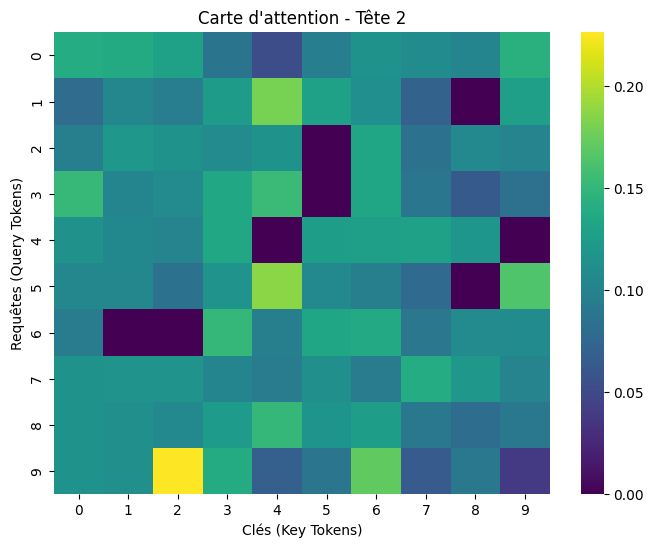

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention_map(weights, head_idx=0, sample_idx=0):
    """
    Visualise la matrice d'attention pour une tête spécifique.
    """
    # weights shape: (batch, heads, seq, seq)
    attn_matrix = weights[sample_idx, head_idx].detach().cpu().numpy()

    plt.figure(figsize=(8, 6))
    sns.heatmap(attn_matrix, annot=False, cmap='viridis')
    plt.title(f"Carte d'attention - Tête {head_idx}")
    plt.xlabel("Clés (Key Tokens)")
    plt.ylabel("Requêtes (Query Tokens)")
    plt.show()

# Visualisation d'une tête de notre test précédent
plot_attention_map(weights, head_idx=2)

## Comparaison avec un modèle pré-entraîné (BERT/DistilBERT)

En milieu académique et professionnel, on compare souvent une architecture 'from scratch' avec un modèle état de l'art. Voici comment charger un modèle DistilBERT pour la même tâche (NLI) via la bibliothèque `transformers`.

In [6]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Chargement d'un modèle léger pré-entraîné
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
bert_model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)

print(f"Modèle {model_name} chargé avec succès.")

# Exemple de tokenisation pour NLI (Prémisse + Hypothèse)
premise = "A man is playing soccer."
hypothesis = "The man is outside."
inputs = tokenizer(premise, hypothesis, return_tensors="pt", padding=True, truncation=True)

with torch.no_grad():
    outputs = bert_model(**inputs)
    logits = outputs.logits

print(f"Logits DistilBERT: {logits}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modèle distilbert-base-uncased chargé avec succès.
Logits DistilBERT: tensor([[0.0270, 0.0063, 0.0913]])


## Synthèse et Réflexion

| Caractéristique | Custom Encoder Stack | Pretrained Transformer (DistilBERT) |
| :--- | :--- | :--- |
| **Complexité** | Faible, facile à modifier | Élevée, architecture optimisée |
| **Performance** | Limitée par les données/temps | Excellente grâce au pré-entraînement |
| **Interprétabilité** | Directe (via nos poids loggués) | Requiert des outils comme Captum ou BertViz |
| **Usage idéal** | Apprentissage, besoins spécifiques | Production, tâches complexes de NLP |

**Insights sur l'attention :**
- L'attention à tête unique risque de manquer des relations nuancées.
- Le Multi-head permet de capturer à la fois la syntaxe (proximité) et la sémantique (relations distantes) simultanément.